## Lab Exercise Week \#4: Naïve Bayes in Machine Learning

### Objective:
The goal of this lab exercise is to understand Naïve Bayes and its application in machine learning. You will apply a naïve bayes classifier to the spam dataset and use it to make predictions.

### Datasets:
For this lab exercise, you'll use the spam.csv dataset from Brightspace.

### Libraries:
`scikit-learn` provides multiple implementations of Naive Bayes that differ on how conditional probabilities are calculated. So the different implementations are suitable for different types of data. 

- `CategorialNB` will work with categorical data once it is processed using an `OrdinalEncoder`
- `GaussianNB` assumes the numerical features have a Gaussian distribution
- `BernoulliNB` binary data
- `MultinomialNB` count data, e.g. word counts, text classification

### Tasks:

#### 1). Data Loading and Libraries:
<ul>
<li>Import all needed libraries.</li>
<li>Load the spam.csv dataset.</li>
<li>Explore the dataset to understand its structure and features.</li>
<li>Select approprate features for a your model.</li>
</ul>

In [ ]:
import numpy as np # numercal conputations
import pandas as pd # handle datasets
import matplotlib.pyplot as plt # visualisation
from collections import Counter # count text words inside text
from sklearn import feature_extraction, model_selection, naive_bayes, metrics  #exgtract features insdie yuor datag / # select models that are related to trainin and test split / NB =classifier / metrics precisino/recal/accuracy and # F1 score... 
from IPython.display import Image # used to display the images...
import warnings # import warnggins  then ignore al wornings
warnings.filterwarnings("ignore")
%matplotlib inline  

#specifued encoding.. so cna to dounter vectorizer correctly
data = pd.read_csv('spam.csv', encoding='latin-1')
# retrivee 1st 1- samples in df
data.head(n=10)

# some unnamed features... can drop them... so classificatino mainly on sentences yuo ahve inside yuor dataset


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
5,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
6,ham,Even my brother is not like to speak with me. ...,NaN,NaN,NaN
7,ham,As per your request 'Melle Melle (Oru Minnamin...,NaN,NaN,NaN
8,spam,WINNER!! As a valued network customer you have...,NaN,NaN,NaN
9,spam,Had your mobile 11 months or more? U R entitle...,NaN,NaN,NaN


#### 2). Data Exploration:
Count how many spam and ham emails it contains and visualise this in a bar chart or pie chart.

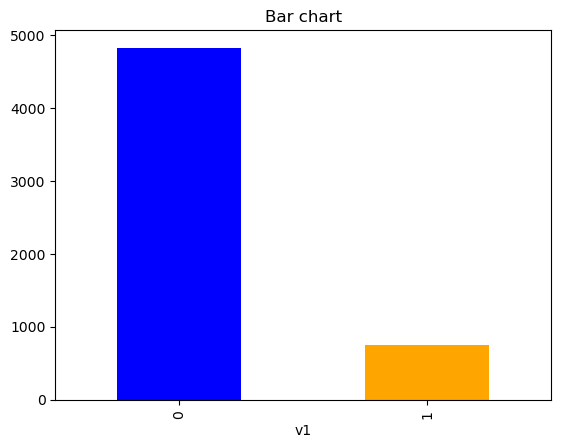

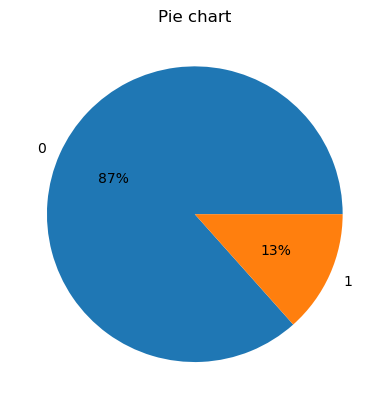

In [ ]:
# how many ham and how many spam...
# 1st  - do count class - how many span and ham >> ussing values.count number of samples per each class...
# sort  = true. alphabetically sort
count_Class=pd.value_counts(data["v1"], sort= True)
# plot bar graphh - cna change colour... and give title..can also use different types of charts... pie for e.g.
count_Class.plot(kind= 'bar', color= ["blue", "orange"])
plt.title('Bar chart')
plt.show()

# can also use different types of charts... pie for e.g.
count_Class.plot(kind = 'pie',  autopct='%1.0f%%')
plt.title('Pie chart')
plt.ylabel('')
plt.show()

# majority are hame.. 0.17
# minority are spam.. 0.13

#### 3). Text Analytics:
Find the frequencies of words in spam and ham messages. The message text will be our descriptive feature. We can use a Counter object to collect frequencies.

In [ ]:
# count nunebr of words for each sentence yuo have....
# first  - specificy which class we a dign wiht word inside it >> give it the col with the etxt
# want just ham labelled... tae highest 20 words frequencis....
count1 = Counter(" ".join(data[data['v1']=='ham']["v2"]).split()).most_common(20)
# save all the words from above - top 20 words based no their frequency...
df1 = pd.DataFrame.from_dict(count1)
# do renamign on df1 - col 1 words in no spane and col 2 count.... indexex zero and 1
df1 = df1.rename(columns={0: "words in non-spam", 1 : "count"})
# do same for spam--- get word count frequency in spam - top 20 # splti sentence into words...rename cols
count2 = Counter(" ".join(data[data['v1']=='spam']["v2"]).split()).most_common(20)
# splti sentence into words...
df2 = pd.DataFrame.from_dict(count2)
# rename cols
df2 = df2.rename(columns={0: "words in spam", 1 : "count_"})

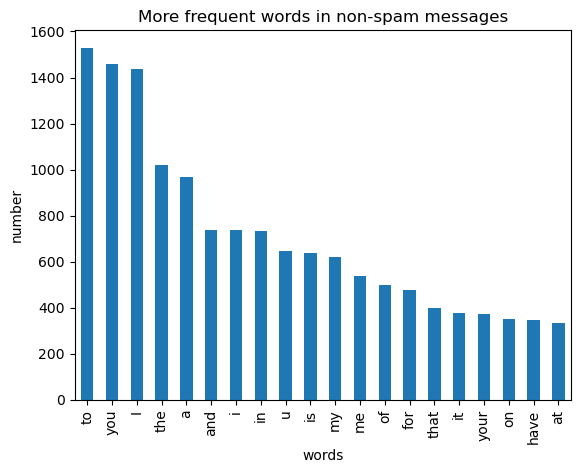

In [ ]:
# df1 has each word inside ham
df1.plot.bar(legend = False)
# values based on their position...arraneg valeus in the below column... words in non-spam... then plto this...
y_pos = np.arange(len(df1["words in non-spam"]))
# plot of top 20 most frequent words based on words extracte d from the counter for ham...
plt.xticks(y_pos, df1["words in non-spam"])
plt.title('More frequent words in non-spam messages')
plt.xlabel('words')
plt.ylabel('number')
plt.show()

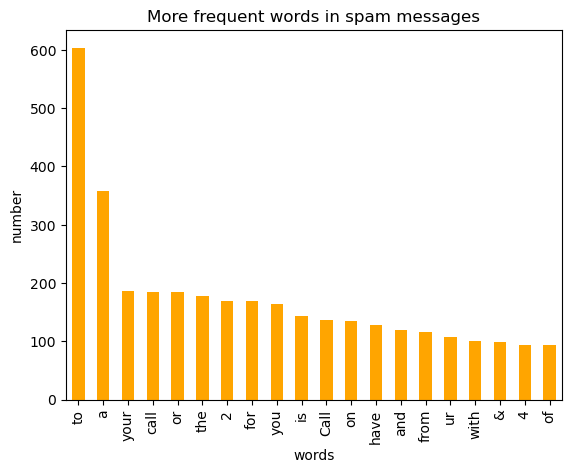

In [ ]:
# repeat for span....
df2.plot.bar(legend = False, color = 'orange')
y_pos = np.arange(len(df2["words in spam"]))
plt.xticks(y_pos, df2["words in spam"])
plt.title('More frequent words in spam messages')
plt.xlabel('words')
plt.ylabel('number')
plt.show()
# can see a lto of words.. eclude the stop words.. "to", "it" etc

We can see that the majority of frequent words in both cases are stop words such as 'to', 'a', 'or' and so on. These are the most common words in the English language.

#### 4). Feature Engineering:
Extract the features, fit and transform by using `sklearn.feature_extraction` and `fit_and_transform`. Check the shape of your features.

In [ ]:
# ise feature exrtaction library count vectoriser use to exclude words from...
# convert each messga from bag of words...# to a vecotr
# remove stop words
# count words appearance
# is multi-lingual
f = feature_extraction.text.CountVectorizer(stop_words = 'english')
#  for  = train?
# 
X = f.fit_transform(data["v2"])
np.shape(X)

(5572, 8411)

#### 5). Training and Test Set Preparation:
Use the `train_test_split` function to split the dataset in training and test (1/3). Test the split by printing out the shape of both sets.

In [ ]:
# encoding for our columns - similar to One Hot encoding - categorical into numercoal labels
data["v1"]=data["v1"].map({'spam':1,'ham':0})
# matrx of the words after doing count vecotorzer...
# text size?

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, data['v1'], test_size=0.33, random_state=42)
# check shape... and name of arrays...
print([np.shape(X_train), np.shape(X_test)])
# x is split intoto 33% for testign and remainder fo rtraining....

[(3733, 8411), (1839, 8411)]


#### 6). Prediction:
Use the `MultinomialNB` classifier from the `naive_bayes` package to fit and predict the target variable. Find out what the regularisation parameter &alpha; means and try to find the best value for it.

In [ ]:
# first thing is list of alpha... 
# using a;pha values for lapplace smoothing .. sart .. end .. number of steps....
list_alpha = np.arange(1/100000, 20, 0.11)
score_train = np.zeros(len(list_alpha)) # an arrary savign values for traingin data
score_test = np.zeros(len(list_alpha)) # craete zero numpy arrary for all wiht same lengths as list aplpha...
recall_test = np.zeros(len(list_alpha)) # save score for traingn for each valeuof alpha...
precision_test= np.zeros(len(list_alpha)) # # same for each value of alpha... 
# 4 variables. 1st one os traingin  / 2nd one testign  / precision for testing...
count = 0 # counter to check how many values for alpha we have  - apha it means for each valeu int hr array we will define a NB classifier...
for alpha in list_alpha:
    bayes = naive_bayes.MultinomialNB(alpha=alpha)
    # train the model for x and y
    bayes.fit(X_train, y_train)
    score_train[count] = bayes.score(X_train, y_train)
    # see the core of the training - for first one / first alpha / will compute the accuracy of NB classifier for traing data and saved inside thsi array..
    score_test[count]= bayes.score(X_test, y_test)
    # same for recall and precision
    # metrics is a built in function...
    recall_test[count] = metrics.recall_score(y_test, bayes.predict(X_test))
    precision_test[count] = metrics.precision_score(y_test, bayes.predict(X_test))
    # increment count by 1 - every time we save into the array index increses until we hit last index of alpha rray
    
    count = count + 1 

#### 7). Evaluation:
The `MultinomialNB` object you used for your prediction, also has variables for `score` (accuracy), `precision` and `recall`. Use them to create a matrix with your results (ideally for different &alpha; values). How good was your prediction on the test set?

In [ ]:
# we wll save all the values inside it 
matrix = np.matrix(np.c_[list_alpha, score_train, score_test, recall_test, precision_test])
# define columsn absed no alpha variables or give descriptive names...
# alpha is value of akpha / accuracy if traingin  / acc f testign etc...
models = pd.DataFrame(data = matrix, columns = 
             ['alpha', 'Train Accuracy', 'Test Accuracy', 'Test Recall', 'Test Precision'])
models.head(n=10)
# check values to make sure that your clasifier is working correctly or not.... 
# training accuracy will not give you an indication  whether thsi classifier is working correctly or not
# as the data is already been seen with the model during the training  d
# b ut testing one is not seen during training, asw e already do the splitting 
# so thsi is the best option to classify yuor model...


# check first 10 rows.. which is first 10 alpha values... ascending order
# incrementing byth approx .11
# accuracy is almost 100% >>> means is workgin fine but check the testgin it is alao 97% so about 2 ^ gap betwene etstgin and tarinnig....



,alpha,Train Accuracy,Test Accuracy,Test Recall,Test Precision
0,0.00001,0.998661,0.974443,0.920635,0.895753
1,0.11001,0.997857,0.976074,0.936508,0.893939
2,0.22001,0.997857,0.977705,0.936508,0.904215
3,0.33001,0.997857,0.977162,0.936508,0.900763
4,0.44001,0.997053,0.977162,0.936508,0.900763
5,0.55001,0.996518,0.976618,0.936508,0.897338
6,0.66001,0.996518,0.976074,0.932540,0.896947
7,0.77001,0.996518,0.976074,0.924603,0.903101
8,0.88001,0.995982,0.976074,0.924603,0.903101
9,0.99001,0.995982,0.976074,0.920635,0.906250


In [ ]:
# to get best model base dni test precision...
# models = df
best_index = models['Test Precision'].idxmax()
# after get lcoation and values... use iloc and index of highest value...
# index location  = iloc..
# retrive eall the columns... if remove : would get onyl the valeu retrieved...
models.iloc[best_index, :]

# this is all the columsn from index based on ??
# training accuracy = 
# check best mdoel based on recall? it woudl eb different...
# check best model based on test accuracy be different again...

alpha             15.510010
Train Accuracy     0.979641
Test Accuracy      0.969549
Test Recall        0.777778
Test Precision     1.000000
Name: 141, dtype: float64

In [ ]:
# predicted value from NB classifier
# buidl a df which will eb CM - confusion matrix..
m_confusion_test = metrics.confusion_matrix(y_test, bayes.predict(X_test))
pd.DataFrame(data = m_confusion_test, columns = ['Predicted 0', 'Predicted 1'],
            index = ['Actual 0', 'Actual 1'])

# this is the solution for the lab....

,Predicted 0,Predicted 1
Actual 0,1587,0
Actual 1,62,190
